In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
from pathlib import Path

### Import data

In [2]:
# path = os.path.abspath('E:/RA/Geert/task1.py')
# dir_path = os.path.dirname(path)
# os.chdir(dir_path)
# excel_file = pd.ExcelFile('Aggregate_CPI_inflation_20230513.xls')

base_dir = Path.cwd()

excel_path = base_dir / "Aggregate_CPI_inflation_20230513.xls"
excel_file = pd.ExcelFile(excel_path)


sheet_quarter = excel_file.sheet_names[0]
sheet_month = excel_file.sheet_names[1]
#quarterly and monthly aggregate CPI data (deseasonalized). The full sample is 1947-2022
data_quarter = excel_file.parse(sheet_quarter, skiprows=2)
data_month = excel_file.parse(sheet_month, skiprows=2)
data_quarter.index = pd.to_datetime(data_quarter['Year'].astype(str) + '-Q' + data_quarter['Quarter'].astype(str))
data_month.index = pd.to_datetime(data_month[['Year', 'Month']].assign(day=1))
data_quarter.columns = ['Year', 'Quarter', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']
data_month.columns = ['Year', 'Month', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']

/var/folders/_w/ndh_5fmn3sl6dqws00y6zbzm0000gp/T/ipykernel_79733/2134866458.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_quarter.index = pd.to_datetime(data_quarter['Year'].astype(str) + '-Q' + data_quarter['Quarter'].astype(str))


### Summary Statistics

In [4]:
sample_data = data_quarter[data_quarter['Year']>1969]
sample_data.iloc[:,2:].describe()

,Price index,Inflation,Forecasted inflation,Inflation shock
count,212.000000,212.000000,212.000000,212.000000
mean,155.123274,0.985211,0.832624,0.152588
std,70.822675,0.862214,0.500391,0.665941
min,38.300000,-3.416988,0.104789,-4.011699
25%,99.075000,0.528033,0.474486,-0.168294
50%,157.200000,0.786865,0.627210,0.102200
75%,217.348500,1.282375,1.016048,0.450343
max,298.990000,4.161248,2.456609,2.172944


In [5]:
for lag_ in range(1, 4):
    autocorrelation = sample_data['Inflation'].autocorr(lag=lag_)
    print(f"Autocorrelation at lag {lag_}: {autocorrelation}")

Autocorrelation at lag 1: 0.5962148596375042
Autocorrelation at lag 2: 0.5336269763073435
Autocorrelation at lag 3: 0.5724923341010191


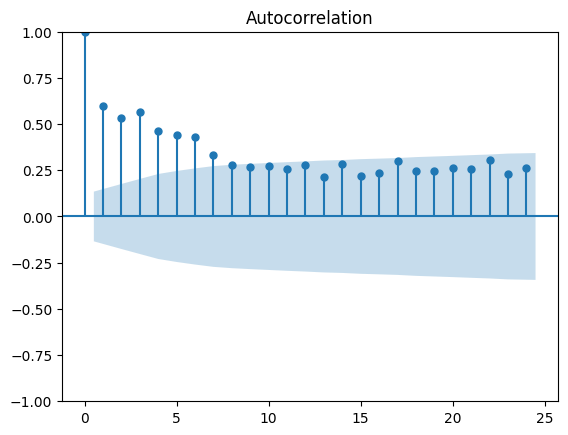

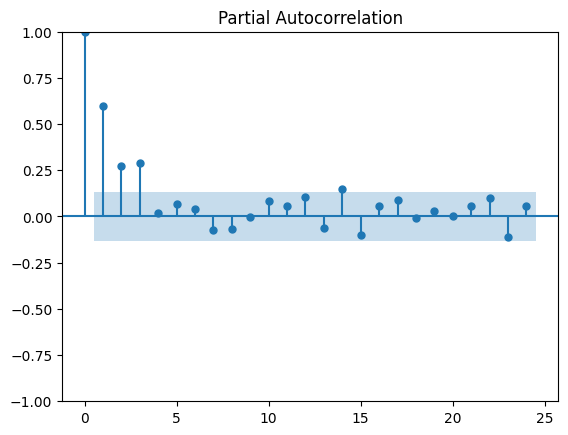

In [6]:
plot_acf(sample_data['Inflation'])
plot_pacf(sample_data['Inflation'])
plt.show()

### Linear regression with HAC covariance matrix

In [10]:
#  Pi(t) = alpha + rho_1 * pi(t-1)  + rho_2 * pi(t-2)   +  phi *  fc(t-1)  + e(t)
sample_data['Inflation_lag_1'] =  sample_data['Inflation'].shift(1)
sample_data['Inflation_lag_2'] =  sample_data['Inflation'].shift(2)
sample_data = sample_data.dropna()

X = sm.add_constant(sample_data[['Inflation_lag_1', 'Inflation_lag_2','Forecasted inflation']] )
y = sample_data['Inflation']
model = sm.OLS(y, X)

# HAC covariance matrix with 3 lag,  Bartlett Kernal
results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 3})
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Inflation   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     33.60
Date:                Tue, 16 May 2023   Prob (F-statistic):           1.16e-17
Time:                        15:05:10   Log-Likelihood:                -200.67
No. Observations:                 206   AIC:                             409.3
Df Residuals:                     202   BIC:                             422.6
Df Model:                           3                                         
Covariance Type:                  HAC                                         
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0761      0.089      0.856      0.392      -0.098       0.250
Inflation_lag_1          0.2855      0.096      2.964      0.003       0.097       0.474
Inflation_lag_2          0.0650      0.126      0.515      0.606      -0.182       0.312
Forecasted inflation     0.6706      0.244      2.747      0.006       0.192       1.149
==============================================================================
Omnibus:                       75.704   Durbin-Watson:                   2.019
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              662.393
Skew:                          -1.122   Prob(JB):                    1.46e-144
Kurtosis:                      11.493   Cond. No.                         8.45
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 3 lags and without small sample correction
"""

In [8]:
#  Pi(t) = alpha + rho_1 * pi(t-1)  + rho_2 * pi(t-2)   +  phi *  fc(t-1)  + e(t)
sample_data['Inflation_lag_1'] =  sample_data['Inflation'].shift(1)
sample_data['Inflation_lag_2'] =  sample_data['Inflation'].shift(2)
sample_data = sample_data.dropna()

X = sm.add_constant(sample_data[['Inflation_lag_1', 'Inflation_lag_2','Forecasted inflation']] )
y = sample_data['Inflation']
model = sm.OLS(y, X)

# HAC covariance matrix with 3 lag,  Bartlett Kernal
results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 3})
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              Inflation   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     33.60
Date:                Mon, 04 May 2026   Prob (F-statistic):           1.16e-17
Time:                        16:32:14   Log-Likelihood:                -200.67
No. Observations:                 206   AIC:                             409.3
Df Residuals:                     202   BIC:                             422.6
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0761 

In [13]:
print('HAC Covariance matrix')
cov_hac(results, nlags=3)

HAC Covariance matrix


array([[ 0.00805821,  0.0006328 ,  0.00398393, -0.01414852],
       [ 0.0006328 ,  0.00946285,  0.00448203, -0.01507517],
       [ 0.00398393,  0.00448203,  0.01622397, -0.02588199],
       [-0.01414852, -0.01507517, -0.02588199,  0.06077786]])

### EGARCH for the regression residuals 

In [14]:
am = arch_model(results.resid, mean='Constant', vol='EGARCH',)
res = am.fit(update_freq = 10)
res.summary()

Iteration:     10,   Func. Count:     61,   Neg. LLF: 184.049756581743
Optimization terminated successfully    (Exit mode 0)
            Current function value: 184.0497530606567
            Iterations: 12
            Function evaluations: 70
            Gradient evaluations: 12


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - EGARCH Model Results                     
==============================================================================
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -184.050
Distribution:                  Normal   AIC:                           376.100
Method:            Maximum Likelihood   BIC:                           389.411
                                        No. Observations:                  206
Date:                Tue, May 16 2023   Df Residuals:                      205
Time:                        15:08:02   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu            -0.0678  3.730e-02     -1.817  6.925e-02 [ -0.141,5.339e-03]
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega         -0.1669      0.179     -0.930      0.352 [ -0.518,  0.185]
alpha[1]       0.6481      0.250      2.595  9.471e-03 [  0.159,  1.138]
beta[1]        0.7817      0.124      6.324  2.554e-10 [  0.539,  1.024]
========================================================================

Covariance estimator: robust
"""

In [10]:
am = arch_model(results.resid, mean='Constant', vol='EGARCH',)
res = am.fit(update_freq = 10)
print(res.summary())

Iteration:     10,   Func. Count:     61,   Neg. LLF: 184.04975658060232
Optimization terminated successfully    (Exit mode 0)
            Current function value: 184.04975306054013
            Iterations: 12
            Function evaluations: 70
            Gradient evaluations: 12
                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -184.050
Distribution:                  Normal   AIC:                           376.100
Method:            Maximum Likelihood   BIC:                           389.411
                                        No. Observations:                  206
Date:                Mon, May 04 2026   Df Residuals:                      205
Time:                        16:41:35   Df Model:                            1
      

### EGARCH for the predicted errors

In [15]:
am = arch_model(sample_data['Inflation shock'],mean='Constant',vol='EGARCH',)
res = am.fit(update_freq = 10)
res.summary()

Iteration:     10,   Func. Count:     62,   Neg. LLF: 189.81837491915525
Optimization terminated successfully    (Exit mode 0)
            Current function value: 189.81833108732638
            Iterations: 12
            Function evaluations: 72
            Gradient evaluations: 12


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - EGARCH Model Results                     
==============================================================================
Dep. Variable:        Inflation shock   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -189.818
Distribution:                  Normal   AIC:                           387.637
Method:            Maximum Likelihood   BIC:                           400.948
                                        No. Observations:                  206
Date:                Tue, May 16 2023   Df Residuals:                      205
Time:                        15:08:56   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         3.5441e-03  4.907e-02  7.222e-02      0.942 [-9.264e-02,9.973e-02]
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega         -0.1049      0.141     -0.745      0.456 [ -0.381,  0.171]
alpha[1]       0.6097      0.181      3.368  7.569e-04 [  0.255,  0.965]
beta[1]        0.8391  9.009e-02      9.314  1.235e-20 [  0.662,  1.016]
========================================================================

Covariance estimator: robust
"""